### imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, stats
from skimage import measure
import pandas as pd
from config import get_control_file, get_patient_file 

### array to df

In [2]:
# load npy file for participant
participant = 1
trial_number = 5
file_path = get_control_file(participant)
data = np.load(file_path)  # shape: (channels, time, trials)
trial_idx = trial_number - 1
trial_data = data[:, :, trial_idx]

df = pd.DataFrame(trial_data.T, columns=['x', 'y', 'pupil']) # transpose from (channels, time)

### pupil dilation

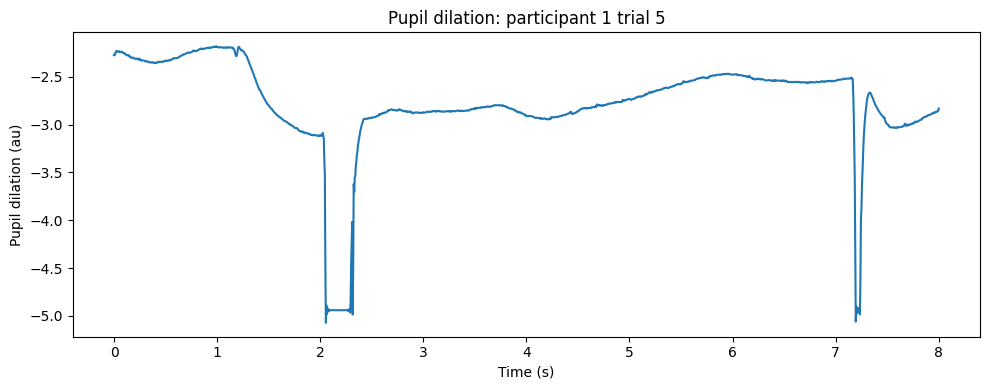

In [3]:
fs = 200  # sampling frequency Hz
samples = 1601

time = np.arange(samples) / fs

plt.figure(figsize=(10,4))
plt.plot(time, df['pupil'])
plt.title(f'Pupil dilation: participant {participant} trial {trial_number}')
plt.xlabel('Time (s)')
plt.ylabel('Pupil dilation (au)')
plt.tight_layout()
plt.show()

### blink check

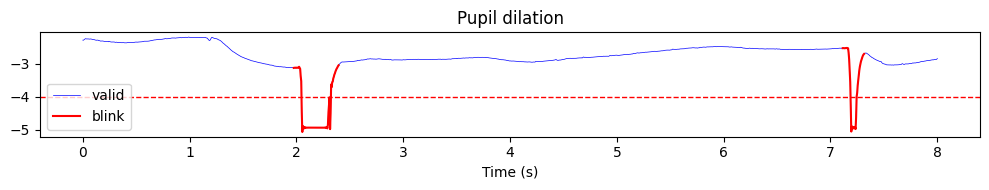

In [4]:
blink_mask = df['pupil'] < -4.0 # True = blink, False = valid
blink_mask = ndimage.binary_dilation(blink_mask, iterations=15)
time = np.arange(samples) / fs

# trial_pupil = ndimage.binary_dilation(trial_pupil)

plt.figure(figsize=(10,2))

blink_p = np.where(blink_mask, df['pupil'], np.nan)  # non-blink points become gaps
plt.plot(time, df['pupil'], color='blue', label='valid', lw = 0.5)
plt.plot(time, blink_p, color='red', label='blink')
plt.axhline(y=-4, color='red', linestyle='--', linewidth=1)

'''
# valid segments
plt.plot(time[~blink_mask], df['pupil'][~blink_mask],
         color='blue', label='valid')

# blink segments
plt.plot(time[blink_mask], df['pupil'][blink_mask],
         color='red', label='blink')
'''
         
plt.title(f'Pupil dilation')
plt.xlabel('Time (s)')
plt.legend()
plt.tight_layout()
plt.show()

### visualising the trial

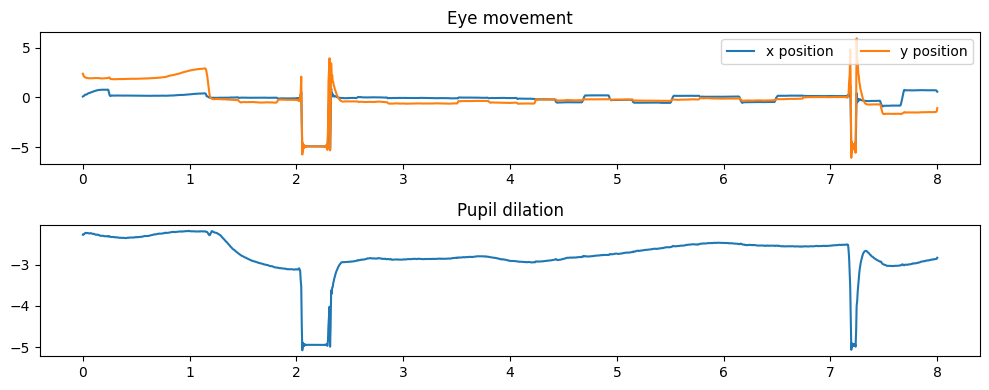

In [5]:
plt.figure(figsize = (10,4))
plt.subplot(2,1,1)
plt.plot(time, df['x'], label = 'x position')
plt.subplot(2,1,1)
plt.plot(time, df['y'], label = 'y position')
plt.legend(loc = 'upper right', ncol = 2)
plt.title('Eye movement')

plt.subplot(2,1,2)
plt.title('Pupil dilation')
plt.plot(time, df['pupil'])
plt.tight_layout()

plt.show()

### ignoring blinks

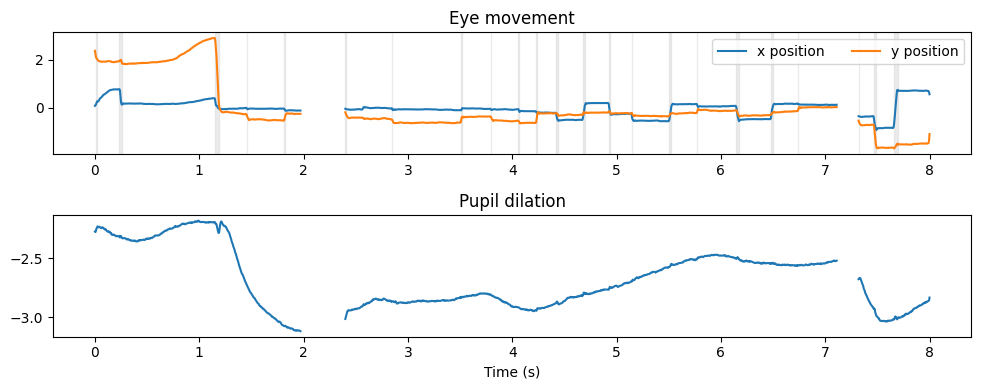

In [6]:
df_clean = df.copy()
df_clean.loc[blink_mask, :] = np.nan

# detect saccade intervals on blink-cleaned eye position
merging_ms = 10
thr_z = 1
iters = max(1, int((merging_ms / 1000.0) * fs))

x = df_clean['x']
y = df_clean['y']
speed = np.sqrt(np.diff(x) ** 2 + np.diff(y) ** 2)
speed_z = stats.zscore(speed, nan_policy='omit')
raw = speed_z > thr_z
saccades = ndimage.binary_dilation(raw, iterations=iters)
saccades = ndimage.binary_erosion(saccades, iterations=iters)
labelled, _ = ndimage.label(saccades.astype(np.uint8))
regions = ndimage.find_objects(labelled)
time_speed = np.arange(len(speed)) / fs

plt.figure(figsize = (10,4))
ax1 = plt.subplot(2,1,1)

# shade detected saccades in the background (panel C, first graph)
for r in regions:
    if r is None:
        continue
    start = r[0].start
    stop = r[0].stop
    ax1.axvspan(time_speed[start], time_speed[max(start, stop - 1)], color='0.85', alpha=0.5, zorder=0)

ax1.plot(time, df_clean['x'], label = 'x position')
ax1.plot(time, df_clean['y'], label = 'y position')
ax1.legend(loc = 'upper right', ncol = 2)
ax1.set_title('Eye movement')

ax2 = plt.subplot(2,1,2)
ax2.set_title('Pupil dilation')
ax2.plot(time, df_clean['pupil'])
ax2.set_xlabel('Time (s)')
plt.tight_layout()

plt.show()



### saccade info:

number of saccades = 23


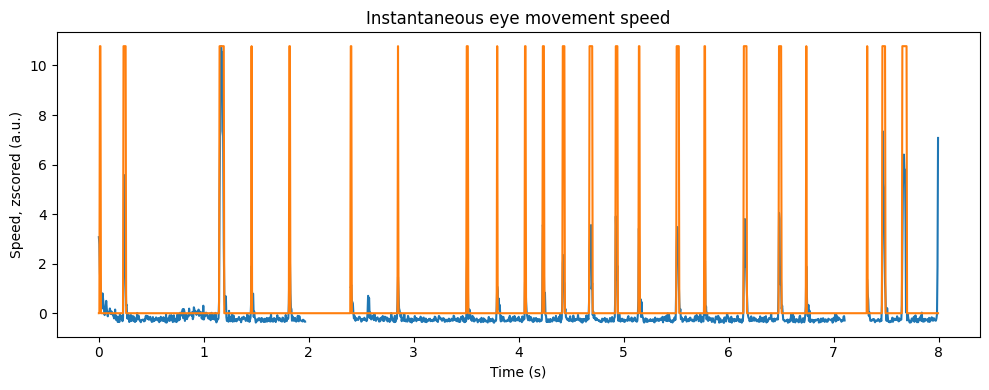

number of saccades = 23
    label  start_s  end_s  duration_ms  mean_speed  max_speed
0       1    0.010  0.015         10.0    1.404130   1.642381
1       2    0.235  0.255         25.0    3.217499   5.573823
2       3    1.150  1.190         45.0    7.754506  10.780140
3       4    1.455  1.455          5.0    1.903254   1.903254
4       5    1.815  1.820         10.0    2.035982   2.215318
5       6    2.400  2.405         10.0    1.094382   1.135024
6       7    2.850  2.850          5.0    1.463098   1.463098
7       8    3.505  3.515         15.0    1.865961   2.795620
8       9    3.795  3.795          5.0    1.079624   1.079624
9      10    4.060  4.065         10.0    1.281172   1.315732
10     11    4.230  4.240         15.0    2.819452   3.566691
11     12    4.420  4.435         20.0    1.710060   2.346868
12     13    4.675  4.700         30.0    2.501302   3.554684
13     14    4.925  4.940         20.0    2.563118   3.910775
14     15    5.145  5.150         10.0    2.49

In [7]:
samples = data.shape[1]
trials = data.shape[2]

merging_ms = 10
thr_z = 1

x = df_clean['x']
y = df_clean['y']
pupil = df_clean['pupil']

xdiff = np.diff(x) ** 2
ydiff = np.diff(y) ** 2
speed = np.sqrt(xdiff + ydiff)
speed_z = stats.zscore(speed, nan_policy = 'omit')
time = np.arange(len(speed)) / fs  # seconds (fs = 200Hz)

plt.figure(figsize=(10,4))

plt.plot(time, speed_z)


plt.title('Instantaneous eye movement speed')
plt.xlabel('Time (s)')
plt.ylabel('Speed, zscored (a.u.)')
plt.tight_layout()

# --- saccade statistics ---
iters = max(1, int((merging_ms / 1000.0) * fs))   # samples to merge at fs Hz

raw = speed_z > thr_z
# print('raw > thr_z:', int(raw.sum()))
# print('iters (samples merged):', iters)
# merge short gaps between supra-threshold samples
saccades = ndimage.binary_dilation(raw, iterations=iters)
saccades = ndimage.binary_erosion(saccades, iterations=iters)
# optional gentle cleanup to remove isolated single-sample noise (commented by default)
# saccades = ndimage.binary_opening(saccades)

labelled, n = ndimage.label(saccades.astype(np.uint8))
regions = ndimage.find_objects(labelled)

# for i in regions: 
#     start = (time[i[0].start]).round(4)
#     end = (time[i[0].stop - 1]).round(4)
#     duration_ms = ((end - start)* 1000).round(4)
#     print(f'{start}s -> {end}s  (duration {duration_ms}ms)')

movement = saccades
print(f'number of saccades = {n}')

plt.plot(time, movement*np.nanmax(speed_z))

plt.show()

labels = measure.label(movement.astype(np.uint8), connectivity=1)
props = measure.regionprops_table(
    labels[:, None],                 # make it 2-D for skimage
    intensity_image=speed_z[:, None],  # to get mean/max speed per saccade
    properties=('label', 'area', 'bbox', 'mean_intensity', 'max_intensity')
)

stats_df = pd.DataFrame(props).rename(
    columns = {
        'area': 'n_samples',
        'bbox-0': 'start_idx',
        'bbox-2': 'end_idx_exclusive',
        'mean_intensity': 'mean_speed',
        'max_intensity': 'max_speed'
    }
)

stats_df['end_idx'] = stats_df['end_idx_exclusive'] - 1
stats_df['start_s'] = stats_df['start_idx'] / fs
stats_df['end_s'] = stats_df['end_idx'] / fs
stats_df['duration_ms'] = (stats_df['n_samples'] / fs) * 1000

# throw away durations <10ms


print(f"number of saccades = {len(stats_df)}")
print(stats_df[['label','start_s','end_s','duration_ms','mean_speed','max_speed']])

### exclude noisy trials

some trials (eg. participant 10 trial 23) are super noisy - can just be thrown out entirely on basis of variance?

In [8]:
# load npy file for participant
participant = 5
trial_number = 36
file_path = f'/Users/anji/Desktop/lab project/EyeData/controls/ctrl_{participant}.npy'
data = np.load(file_path)  # shape: (channels, time, trials)
trial_idx = trial_number - 1
trial_data = data[:, :, trial_idx]

df = pd.DataFrame(trial_data.T, columns=['x', 'y', 'pupil']) # transpose from (channels, time)

pupvar = np.var(df['pupil'])
xvar = np.var(df['x'])
yvar = np.var(df['y'])
print(f'''variance: \n pupil = {pupvar},
      x = {xvar},
      y = {yvar}''')

variance: 
 pupil = 1.532888113418944e-10,
      x = 8.292741141595373e-11,
      y = 6.194608408863724e-11
